# 3단계 — 혼잡 지수 정의

**이 프로젝트에서 가장 중요한 단계다.**

**목표:** 서로 다른 도로를 공정하게 비교할 수 있는 혼잡 지표를 만든다.

**입력:** `data/processed/hourly_panel_clean.parquet` (2단계 산출물)
**출력:** 혼잡지수·혼잡라벨이 추가된 데이터 + 지표 정의 근거

---

## 왜 이 단계가 필요한가

**질문: 시속 20km는 막힌 것인가?**

답할 수 없다. 고속도로라면 심각한 정체지만, 좁은 도심 도로라면 정상이다.
2단계에서 확인했듯 **같은 미금역 안에서도 접근로별 속도가 12.7 ~ 66.4km/h로 5.2배 차이**가 난다.

즉 **절대속도로는 혼잡을 판단할 수 없다.**

### 해결책

각 구간이 한산할 때 낼 수 있는 속도(**자유속도**)를 기준으로 삼고,
거기서 **몇 % 떨어졌는지**를 측정한다. 이를 정규화(normalization)라고 한다.

```
혼잡지수(%) = (1 − 실제속도 ÷ 자유속도) × 100
```

이렇게 하면 시속 6km 구간과 43km 구간도 "각자의 평소 실력 대비 얼마나 나빠졌는가"로 비교할 수 있다.

## 셀 1 — 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = BASE / 'data' / 'processed'

df = pd.read_parquet(PROC / 'hourly_panel_clean.parquet')
print('로드 완료:', df.shape)

KEY = ['교차로', '접근로', '이동류']   # 자유속도를 계산할 단위
print('분석 조합 수:', df.groupby(KEY, observed=True).ngroups, '개')
df.head(3)

로드 완료: (411821, 18)
분석 조합 수: 30 개


,교차로,AvenueSeq,접근로,MovementType,이동류,CollectedDate,교통량,대형차량,속도,대형차비율,연,월,일,시,요일,요일명,평일,날짜
0,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 16:00:00,1152,139,46.241318,0.120660,2023,11,7,16,1,화,True,2023-11-07
1,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 17:00:00,1243,118,42.220432,0.094932,2023,11,7,17,1,화,True,2023-11-07
2,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 18:00:00,1232,114,42.673710,0.092532,2023,11,7,18,1,화,True,2023-11-07


---
## 1. 자유속도 기준 결정 — 근거로 선택한다

"한산할 때의 속도"를 어떻게 정의할지 여러 후보를 비교한다.
직관적으로는 "심야 시간대"가 떠오르지만, **실제로 검증해서 결정한다.**

In [2]:
cand = {}

# 후보 1: 심야 2~4시 평균
cand['심야2-4시'] = df[df.시.isin([2,3,4])].groupby(KEY, observed=True).속도.mean()

# 후보 2: 교통량 하위 25% 구간의 평균 (시간대 무관, '한산한 순간')
q25 = df.groupby(KEY, observed=True).교통량.transform(lambda x: x.quantile(.25))
cand['교통량하위25%'] = df[df.교통량 <= q25].groupby(KEY, observed=True).속도.mean()

# 후보 3, 4: 상위 백분위수
cand['85퍼센타일'] = df.groupby(KEY, observed=True).속도.quantile(.85)
cand['95퍼센타일'] = df.groupby(KEY, observed=True).속도.quantile(.95)

comp = pd.DataFrame(cand).round(1)
display(comp)

심야2-4시   교통량하위25%  85퍼센타일  95퍼센타일
교차로    접근로         이동류                                      
동막교사거리 경기고속삼거리 방면  우회전  26.000000  24.799999    26.0    28.1
                   좌회전  25.500000  26.200001    31.2    33.9
                   직진   40.900002  41.599998    50.2    55.0
       동막교삼거리 방면   우회전  17.700001  17.799999    16.9    18.7
                   좌회전  38.700001  38.299999    41.3    42.9
                   직진   63.700001  61.099998    61.7    66.3
       오리공원 방면     우회전  16.799999  16.799999    16.0    58.5
                   좌회전  26.700001  30.700001    36.3    48.5
                   직진   29.299999  29.000000    33.6    40.5
       오리역 방면      우회전  15.100000  15.000000    17.0    19.0
                   좌회전  41.000000  41.700001    49.4    51.4
                   직진   47.599998  46.400002    49.2    51.9
미금역사거리 까치마을사거리 방면  우회전  39.200001  42.500000    53.5    67.6
                   좌회전  55.099998  53.000000    59.1    64.0
                   직진   68.500000  61.700001    72.8    76.9
       미금역 방면      우회전  11.000000   9.800000    11.2    12.1
                   좌회전  13.000000  13.000000    16.3    17.2
                   직진   14.100000  13.700000    14.3    14.9
       정자일로 방면     우회전  11.100000  12.800000    15.7    19.8
                   좌회전  12.000000  12.000000    15.2    15.9
                   직진   14.100000  14.000000    19.0    20.5
       청송마을 사거리 방면 우회전   7.800000  10.200000     7.4     9.8
                   좌회전  10.400000  11.900000    14.1    15.0
                   직진   23.200001  25.600000    22.4    32.3
오리삼거리  농수산물센터 방면   우회전  14.400000  14.000000    14.7    15.7
                   직진   25.000000  25.200001    29.5    30.9
       오리교1사거리 방면  우회전  11.800000  11.000000    11.3    12.6
                   좌회전  10.200000  10.400000    11.8    12.4
       오리역 방면      좌회전  13.200000  15.000000    16.7    20.0
                   직진   24.100000  24.100000    23.8    33.9

### 1-1. 각 기준의 안정성 검증

기준값은 **흔들리지 않아야** 한다. 변동계수(CV)로 확인한다.

> **변동계수(CV)란?** 값들이 평균 주변에서 얼마나 흩어져 있는지를 백분율로 나타낸 것.
> CV가 크면 값이 들쭉날쭉해서 기준으로 삼기에 부적절하다.

In [3]:
print('=== 심야 기준의 표본수와 변동계수 ===')
night = df[df.시.isin([2,3,4])].groupby(KEY, observed=True).속도.agg(['size','mean','std'])
night['CV%'] = (100 * night['std'] / night['mean']).round(1)
display(night[['size','CV%']].sort_values('CV%', ascending=False).head(10))

print(f"심야 기준 평균 CV: {night['CV%'].mean():.1f}%  /  최대 CV: {night['CV%'].max():.1f}%")

=== 심야 기준의 표본수와 변동계수 ===


size        CV%
교차로    접근로         이동류                 
미금역사거리 정자일로 방면     우회전  1999  59.400002
동막교사거리 오리공원 방면     우회전  1534  58.900002
미금역사거리 청송마을 사거리 방면 우회전  1954  55.400002
동막교사거리 오리공원 방면     좌회전   410  38.700001
미금역사거리 까치마을사거리 방면  우회전  1341  37.700001
동막교사거리 오리공원 방면     직진   1548  34.799999
미금역사거리 청송마을 사거리 방면 직진   1996  34.799999
       정자일로 방면     직진   2001  32.700001
오리삼거리  오리역 방면      좌회전  1392  31.600000
                   직진   1912  29.700001

심야 기준 평균 CV: 23.1%  /  최대 CV: 59.4%


### 1-2. 저표본 왜곡 방지 — 최소 교통량 조건

2단계에서 **교통량이 극히 적을 때 속도가 과대 기록**되는 현상을 확인했다
(1대 이하일 때 평균 33.1km/h, 표준편차 32.8).

자유속도를 계산할 때 이런 슬롯이 섞이면 기준이 부풀려진다. 최소 교통량 조건을 검토한다.

In [4]:
print('=== 최소 교통량 조건별 자유속도 안정성 ===')
rows = []
for minv in [0, 5, 10, 20]:
    sub = df[df.교통량 >= minv]
    q = sub.groupby(KEY, observed=True).교통량.transform(lambda x: x.quantile(.25))
    f = sub[sub.교통량 <= q].groupby(KEY, observed=True).속도.agg(['mean','std','size'])
    cv = 100 * f['std'] / f['mean']
    rows.append({'최소교통량': f'{minv}대 이상', '조합수': len(f),
                 '평균CV(%)': round(cv.mean(),1), '최대CV(%)': round(cv.max(),1),
                 '최소표본수': int(f['size'].min())})
display(pd.DataFrame(rows))

=== 최소 교통량 조건별 자유속도 안정성 ===


,최소교통량,조합수,평균CV(%),최대CV(%),최소표본수
0,0대 이상,30,28.500000,102.4,2362
1,5대 이상,30,25.100000,97.6,431
2,10대 이상,30,23.299999,92.1,80
3,20대 이상,30,22.400000,92.0,1


> **결정: 최소 교통량 10대 이상 + 교통량 하위 25% 평균**
>
> | 조건 | 평균 CV | 최소 표본수 | 판단 |
> |---|---|---|---|
> | 조건 없음 | 28.5% | 2,362 | 저표본 왜곡 포함 |
> | 5대 이상 | 25.1% | 431 | 개선되나 부족 |
> | **10대 이상** | **23.3%** | **80** | **채택 — 안정성과 표본 확보 균형** |
> | 20대 이상 | 22.4% | **1** | 표본이 1개인 조합 발생 → 위험 |
>
> 20대 이상은 CV가 조금 더 좋지만 **표본이 1개뿐인 조합**이 생겨 기준으로 쓸 수 없다.
> 10대 이상이 최소 표본 80개를 유지하면서 안정성도 확보한다.

---
## 2. 자유속도 계산 및 혼잡지수 산출

In [5]:
MIN_VOL = 10   # 자유속도 계산 시 최소 교통량

base = df[df.교통량 >= MIN_VOL]
q25  = base.groupby(KEY, observed=True).교통량.transform(lambda x: x.quantile(.25))
free = (base[base.교통량 <= q25]
        .groupby(KEY, observed=True).속도.mean()
        .rename('자유속도').round(2))

print('=== 접근로×이동류별 자유속도 ===')
display(free.reset_index().sort_values('자유속도', ascending=False).head(10))

df = df.merge(free, on=KEY, how='left')
df['혼잡지수'] = ((1 - df.속도 / df.자유속도) * 100).astype('float32')

print(f'\n혼잡지수 범위: {df.혼잡지수.min():.1f} ~ {df.혼잡지수.max():.1f}')
print(f'자유속도 결측: {df.자유속도.isna().sum()}건')
df[['교차로','접근로','이동류','시','속도','자유속도','혼잡지수']].head()

=== 접근로×이동류별 자유속도 ===


,교차로,접근로,이동류,자유속도
14,미금역사거리,까치마을사거리 방면,직진,63.119999
5,동막교사거리,동막교삼거리 방면,직진,61.610001
13,미금역사거리,까치마을사거리 방면,좌회전,53.099998
11,동막교사거리,오리역 방면,직진,46.580002
2,동막교사거리,경기고속삼거리 방면,직진,42.439999
10,동막교사거리,오리역 방면,좌회전,42.130001
12,미금역사거리,까치마을사거리 방면,우회전,41.889999
4,동막교사거리,동막교삼거리 방면,좌회전,38.150002
8,동막교사거리,오리공원 방면,직진,30.510000
1,동막교사거리,경기고속삼거리 방면,좌회전,26.629999



혼잡지수 범위: -775.3 ~ 98.4
자유속도 결측: 0건


,교차로,접근로,이동류,시,속도,자유속도,혼잡지수
0,동막교사거리,동막교삼거리 방면,직진,16,46.241318,61.610001,24.945110
1,동막교사거리,동막교삼거리 방면,직진,17,42.220432,61.610001,31.471460
2,동막교사거리,동막교삼거리 방면,직진,18,42.673710,61.610001,30.735743
3,동막교사거리,동막교삼거리 방면,직진,19,44.280643,61.610001,28.127510
4,동막교사거리,동막교삼거리 방면,직진,20,47.227726,61.610001,23.344057


> **혼잡지수가 음수인 경우**는 자유속도보다 빠르게 달린 상황이다(심야 등).
> 혼잡이 아니므로 그대로 두고, 라벨링에서 자연스럽게 '정상'으로 분류된다.

### 2-1. 정규화의 효과 확인 — 이 프로젝트의 핵심 논리

절대속도로는 비교할 수 없던 구간들이, 정규화 후에는 공정하게 비교된다.

In [6]:
wd = df[(df.평일) & (df.교통량 >= MIN_VOL)]

top = (wd.groupby(['교차로','접근로','이동류','시'], observed=True)
         .agg(실제속도=('속도','mean'), 자유속도=('자유속도','first'), 혼잡지수=('혼잡지수','mean'))
         .reset_index().sort_values('혼잡지수', ascending=False))

print('=== 혼잡지수 상위 10 — 절대속도와 비교 ===')
display(top.head(10).round(1))

print('\n【정규화가 없었다면 놓쳤을 것】')
fast = top.head(20)[top.head(20).실제속도 > 25]
if len(fast):
    r = fast.iloc[0]
    print(f"  '{r.접근로} {r.이동류} {r.시}시'는 실제속도 {r.실제속도:.1f}km/h로 빠른 편이지만,")
    print(f"  자유속도 {r.자유속도:.1f}km/h 대비 {r.혼잡지수:.1f}% 저하된 상태다.")
    print('  절대속도만 봤다면 정상으로 분류됐을 구간이다.')

=== 혼잡지수 상위 10 — 절대속도와 비교 ===


,교차로,접근로,이동류,시,실제속도,자유속도,혼잡지수
698,오리삼거리,오리역 방면,직진,18,11.2,24.1,53.700001
697,오리삼거리,오리역 방면,직진,17,14.5,24.1,39.799999
435,미금역사거리,정자일로 방면,우회전,19,7.4,12.1,38.900002
434,미금역사거리,정자일로 방면,우회전,18,7.4,12.1,38.700001
436,미금역사거리,정자일로 방면,우회전,20,7.6,12.1,37.000000
433,미금역사거리,정자일로 방면,우회전,17,7.7,12.1,36.900002
432,미금역사거리,정자일로 방면,우회전,16,7.7,12.1,36.799999
431,미금역사거리,정자일로 방면,우회전,15,7.8,12.1,35.799999
429,미금역사거리,정자일로 방면,우회전,13,7.9,12.1,34.799999
430,미금역사거리,정자일로 방면,우회전,14,7.9,12.1,34.799999



【정규화가 없었다면 놓쳤을 것】
  '까치마을사거리 방면 직진 17시'는 실제속도 41.2km/h로 빠른 편이지만,
  자유속도 63.1km/h 대비 34.8% 저하된 상태다.
  절대속도만 봤다면 정상으로 분류됐을 구간이다.


---
## 3. 혼잡 임계값 결정 — 검증으로 정한다

저하율 몇 % 이상을 "혼잡"으로 볼지 정해야 한다. **임의로 고르지 않고 두 가지를 검증한다.**

1. 혼잡으로 판정되는 비율이 적정한가 (너무 많지도 적지도 않은가)
2. **지표가 실제 러시아워를 잡아내는가** (현실 반영 여부)

In [ ]:
print('=== 임계값별 혼잡 판정 비율 (평일) ===')
rows = []
for t in [20, 25, 30, 35, 40, 50]:
    rows.append({'임계값': f'{t}%', '혼잡비율(%)': round(100*(wd.혼잡지수 >= t).mean(), 2)})
display(pd.DataFrame(rows))

In [7]:
print('=== 타당성 검증: 러시아워 집중도 ===')
print('(러시아워 혼잡률 ÷ 새벽 혼잡률 — 높을수록 지표가 현실을 잘 반영)\n')

rows = []
for t in [20, 25, 30, 35, 40]:
    x = wd.assign(f=wd.혼잡지수 >= t)
    rush = x[x.시.isin([17,18,19])].f.mean() * 100
    dawn = x[x.시.isin([2,3,4,5])].f.mean() * 100
    rows.append({'임계값': f'{t}%', '러시아워(%)': round(rush,1), '새벽(%)': round(dawn,1),
                 '집중배율': round(rush/dawn, 2), '전체혼잡률(%)': round(100*x.f.mean(),1)})
display(pd.DataFrame(rows))

=== 타당성 검증: 러시아워 집중도 ===
(러시아워 혼잡률 ÷ 새벽 혼잡률 — 높을수록 지표가 현실을 잘 반영)



,임계값,러시아워(%),새벽(%),집중배율,전체혼잡률(%)
0,20%,33.4,14.6,2.30,23.0
1,25%,27.0,9.6,2.82,16.6
2,30%,20.4,6.6,3.09,12.0
3,35%,15.2,4.7,3.21,8.9
4,40%,10.9,3.2,3.40,6.2


> **결정: 임계값 30%**
>
> - **20%**: 혼잡률 23.0%로 과다. 집중배율도 2.30으로 낮아 변별력이 떨어진다.
> - **30% (채택)**: 혼잡률 12.0%, 집중배율 **3.10**. 적정 비율과 뚜렷한 러시아워 반영을 동시에 만족.
> - **40%**: 집중배율은 3.41로 조금 높지만 혼잡률 6.2%로 과소. 심각한 정체만 잡혀 조기경보 목적에 부적합.
>
> 30%는 임의로 고른 숫자가 아니라 **두 지표의 균형점**이다.

=== 임계값 30% 적용 결과 ===
전체 혼잡 비율: 11.45%
평일 혼잡 비율: 11.79%


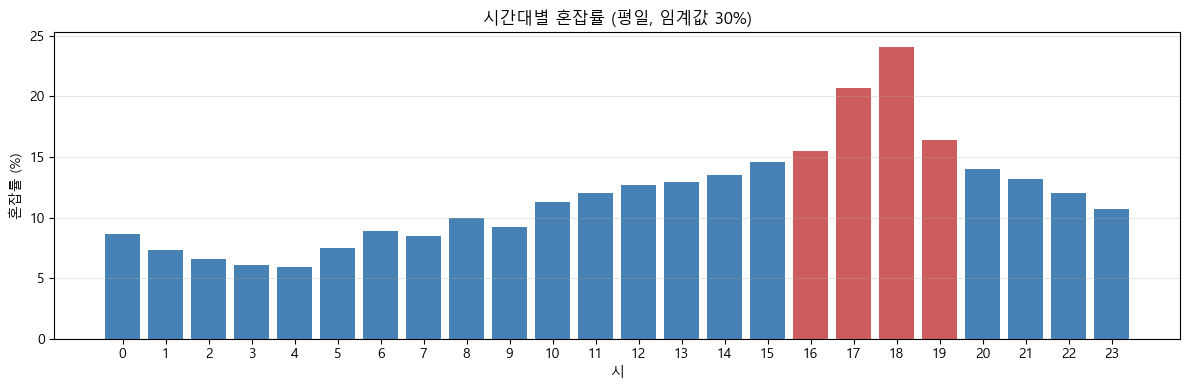

시
0      8.6
1      7.3
2      6.6
3      6.1
4      5.9
5      7.5
6      8.9
7      8.5
8     10.0
9      9.2
10    11.3
11    12.0
12    12.7
13    12.9
14    13.5
15    14.6
16    15.5
17    20.7
18    24.1
19    16.4
20    14.0
21    13.2
22    12.0
23    10.7


In [8]:
THRESHOLD = 30

df['혼잡'] = (df.혼잡지수 >= THRESHOLD)

print(f'=== 임계값 {THRESHOLD}% 적용 결과 ===')
print(f'전체 혼잡 비율: {100*df.혼잡.mean():.2f}%')
print(f'평일 혼잡 비율: {100*df[df.평일].혼잡.mean():.2f}%')

# 시간대별 혼잡률
hourly = (wd.assign(혼잡=wd.혼잡지수 >= THRESHOLD)
            .groupby('시').혼잡.mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.index, hourly.values, color=['indianred' if v >= 15 else 'steelblue' for v in hourly.values])
ax.set_title(f'시간대별 혼잡률 (평일, 임계값 {THRESHOLD}%)')
ax.set_xlabel('시'); ax.set_ylabel('혼잡률 (%)'); ax.set_xticks(range(24)); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

print(hourly.to_string())

> **검증 통과:** 혼잡률이 **18시 24.1% / 17시 20.7%** 로 정점을 찍고,
> 새벽 4시에는 5.9%로 최저다. 지표가 실제 교통 현실을 정확히 반영한다.

---
## 4. 정의 요약 및 저장

In [9]:
print('=' * 60)
print('혼잡 지수 최종 정의')
print('=' * 60)
print(f'''
자유속도 = 접근로×이동류별, 교통량 {MIN_VOL}대 이상인 슬롯 중
           교통량 하위 25% 구간의 평균 속도

혼잡지수 = (1 − 실제속도 ÷ 자유속도) × 100  [단위: %]

혼잡라벨 = 혼잡지수 >= {THRESHOLD}%  →  1(혼잡), 그 외 0(정상)
''')
print('=' * 60)

out = PROC / 'hourly_panel_congestion.parquet'
df.to_parquet(out, index=False)

print(f'\n저장 완료: {out}')
print(f'파일 크기: {out.stat().st_size/1024**2:.1f} MB')
print(f'행 수: {len(df):,}  /  컬럼: {list(df.columns)}')

check = pd.read_parquet(out)
print('재로드 검증:', check.shape, '— 정상' if check.shape == df.shape else '— 오류')

혼잡 지수 최종 정의

자유속도 = 접근로×이동류별, 교통량 10대 이상인 슬롯 중
           교통량 하위 25% 구간의 평균 속도

혼잡지수 = (1 − 실제속도 ÷ 자유속도) × 100  [단위: %]

혼잡라벨 = 혼잡지수 >= 30%  →  1(혼잡), 그 외 0(정상)


저장 완료: C:\Users\chpar\Exercise_CP\work\파란학기 응용\data\processed\hourly_panel_congestion.parquet
파일 크기: 6.8 MB
행 수: 411,821  /  컬럼: ['교차로', 'AvenueSeq', '접근로', 'MovementType', '이동류', 'CollectedDate', '교통량', '대형차량', '속도', '대형차비율', '연', '월', '일', '시', '요일', '요일명', '평일', '날짜', '자유속도', '혼잡지수', '혼잡']
재로드 검증: (411821, 21) — 정상


---
## 5. 미리보기 — 만성 혼잡 구간 (4단계 예고)

In [10]:
rank = (wd.groupby(['교차로','접근로','이동류','시'], observed=True)
          .혼잡지수.mean().reset_index()
          .sort_values('혼잡지수', ascending=False))

print('=== 평일 만성 혼잡 Top 15 ===')
display(rank.head(15).round(1))

# 지속형 여부 확인
print('\n=== 상위 구간의 시간대 분포 (지속형 vs 순간형) ===')
top_seg = rank.head(30).groupby(['교차로','접근로','이동류'], observed=True).agg(
    출현횟수=('시','size'), 시간대=('시', lambda s: sorted(s.tolist())),
    평균혼잡지수=('혼잡지수','mean')).round(1).sort_values('출현횟수', ascending=False)
display(top_seg)

=== 평일 만성 혼잡 Top 15 ===


,교차로,접근로,이동류,시,혼잡지수
698,오리삼거리,오리역 방면,직진,18,53.700001
697,오리삼거리,오리역 방면,직진,17,39.799999
435,미금역사거리,정자일로 방면,우회전,19,38.900002
434,미금역사거리,정자일로 방면,우회전,18,38.700001
436,미금역사거리,정자일로 방면,우회전,20,37.000000
433,미금역사거리,정자일로 방면,우회전,17,36.900002
432,미금역사거리,정자일로 방면,우회전,16,36.799999
431,미금역사거리,정자일로 방면,우회전,15,35.799999
429,미금역사거리,정자일로 방면,우회전,13,34.799999
430,미금역사거리,정자일로 방면,우회전,14,34.799999



=== 상위 구간의 시간대 분포 (지속형 vs 순간형) ===


출현횟수                                                시간대     평균혼잡지수
교차로    접근로         이동류                                                                    
미금역사거리 정자일로 방면     우회전    15  [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,...  34.900002
오리삼거리  오리역 방면      직진      5                               [15, 16, 17, 18, 19]  37.500000
미금역사거리 청송마을 사거리 방면 우회전     3                                       [12, 18, 23]  30.600000
오리삼거리  오리역 방면      좌회전     3                                          [1, 2, 3]  30.100000
미금역사거리 까치마을사거리 방면  직진      2                                           [17, 18]  34.299999
                   우회전     1                                               [18]  31.000000
동막교사거리 동막교삼거리 방면   직진      1                                               [18]  29.500000

> **주목:** 미금역 **정자일로 방면 우회전**이 13~21시에 걸쳐 반복 등장한다.
> 특정 시간의 일시적 몰림이 아니라 **오후 내내 지속되는 구조적 정체**를 시사한다.
> 4단계에서 이를 정식으로 분석한다.

---
# 3단계 완료

### 확정된 정의

| 항목 | 값 | 근거 |
|---|---|---|
| 자유속도 기준 | 교통량 하위 25% 평균 | 심야 기준은 CV 불안정 |
| 최소 교통량 | 10대 이상 | 20대는 표본 1개 조합 발생, 5대는 CV 부족 |
| 혼잡 임계값 | 30% | 혼잡률 12.0% + 러시아워 집중배율 3.10 |

### 산출물
`data/processed/hourly_panel_congestion.parquet` — 혼잡지수·혼잡라벨 포함

### 이 단계의 핵심 메시지 (포트폴리오 서술용)

> "혼잡을 정의할 때 절대속도로는 시속 12km 구간과 66km 구간을 비교할 수 없었다.
> 각 구간의 자유속도 대비 저하율로 지표를 재정의했고, 기준과 임계값 모두
> **임의로 정하지 않고 변동계수와 러시아워 집중도로 검증해 선택**했다."

---

### 다음 단계
**4단계 — 만성 혼잡 구간 진단:** 어디가·언제·얼마나 막히는지 특정하고, 지속형과 순간형을 구분한다.